# Lab 2 — Inspección del dataset (Creative Creatures)

Bocetos vectoriales → formato **stroke-5** para un Sketch-RNN (VAE).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

ROOT = Path("..").resolve() if Path("../train.pkl.gz").exists() else Path(".").resolve()
if not (ROOT / "train.pkl.gz").exists():
    ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from sketchvae.data import (
    denormalize_stroke5,
    load_raw_split,
    sample_to_stroke5,
    stroke5_to_absolute,
)
from sketchvae.viz import draw_sketch, draw_stroke5

OUT = ROOT / "outputs"
print("ROOT =", ROOT)

ROOT = /Users/luis.jauregui/Clases/GM/Lab2


## 1. Resumen numérico

In [2]:
report = json.loads((OUT / "inspect" / "report.json").read_text())
meta = json.loads((OUT / "preprocessed" / "meta.json").read_text())

for split in ("train", "val"):
    raw = report[f"{split}_raw"]
    pre = report[f"{split}_preprocessed"]
    print(f"=== {split} ===")
    print(f"  raw: {raw['n']} sketches | strokes med={raw['strokes_median']:.0f} | points med={raw['points_median']:.0f} (p95={raw['points_p95']:.0f})")
    print(
        f"  stroke-5 kept {int(pre['n_kept'])}/{int(pre['n_in'])} "
        f"| T med={pre['len_median']:.0f} mean={pre['len_mean']:.1f} "
        f"| filtrados long={int(pre['n_long'])}"
    )

print(f"\nepsilon={meta['epsilon']}  max_len={meta['max_len']}  scale={meta['scale']:.4f}")

=== train ===
  raw: 8187 sketches | strokes med=19 | points med=137 (p95=315)
  stroke-5 kept 7330/8187 | T med=130 mean=136.4 | filtrados long=857
=== val ===
  raw: 910 sketches | strokes med=19 | points med=138 (p95=303)
  stroke-5 kept 825/910 | T med=131 mean=136.4 | filtrados long=85

epsilon=2.0  max_len=250  scale=50.8887


## 2. Grids de bocetos crudos

train


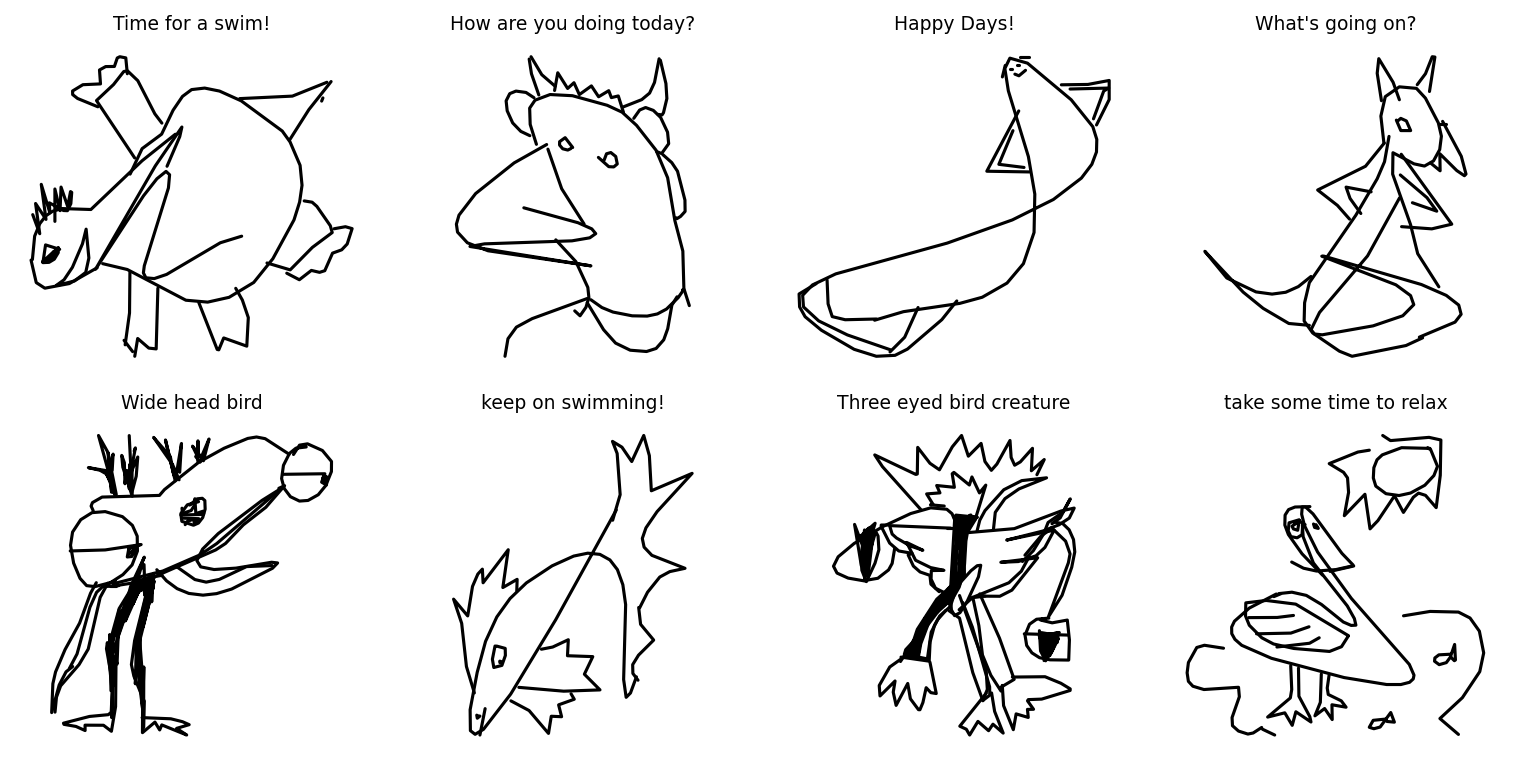

val


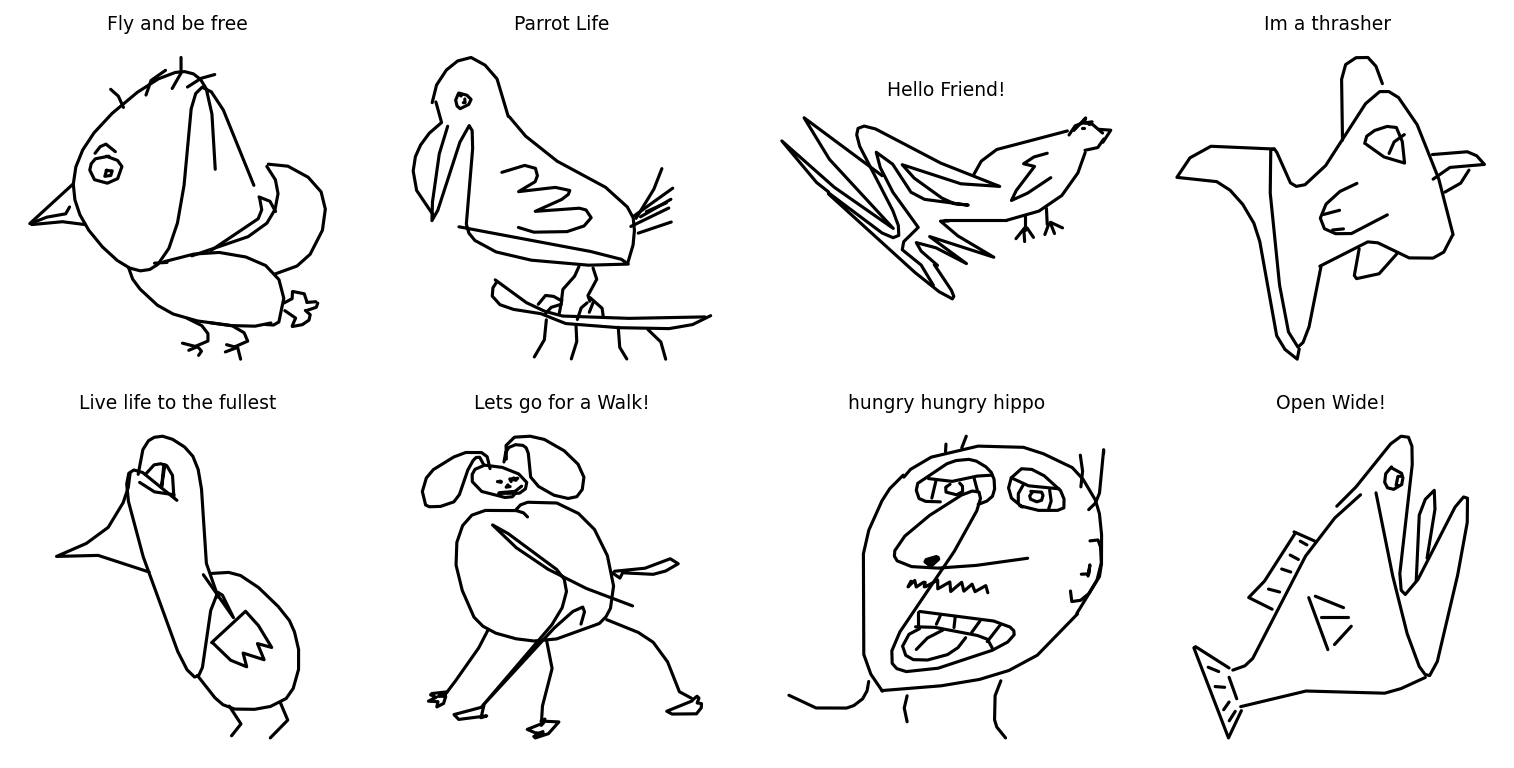

In [3]:
for split in ("train", "val"):
    path = OUT / "inspect" / f"{split}_raw_grid.png"
    print(split)
    display(Image(filename=str(path)))

## 3. Raw vs stroke-5 (misma criatura)

--- train ---


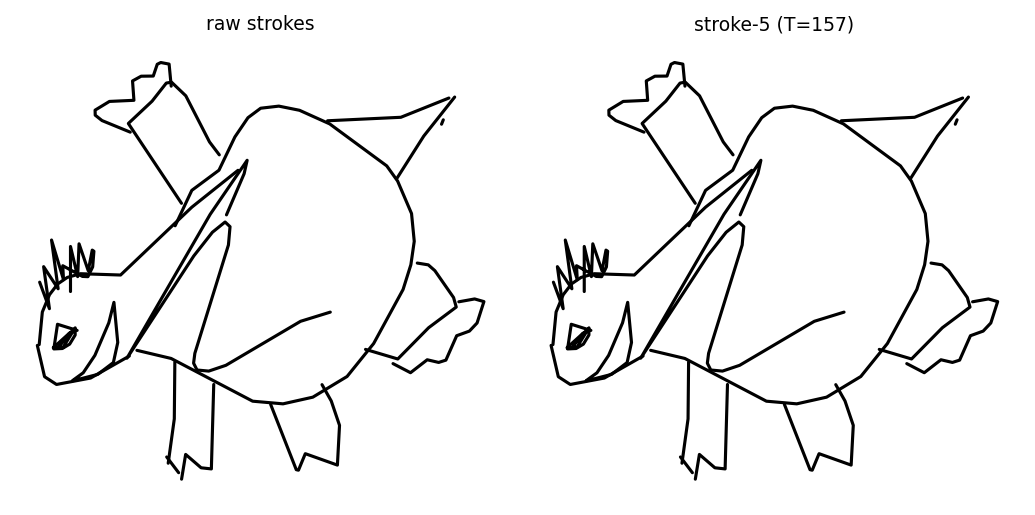

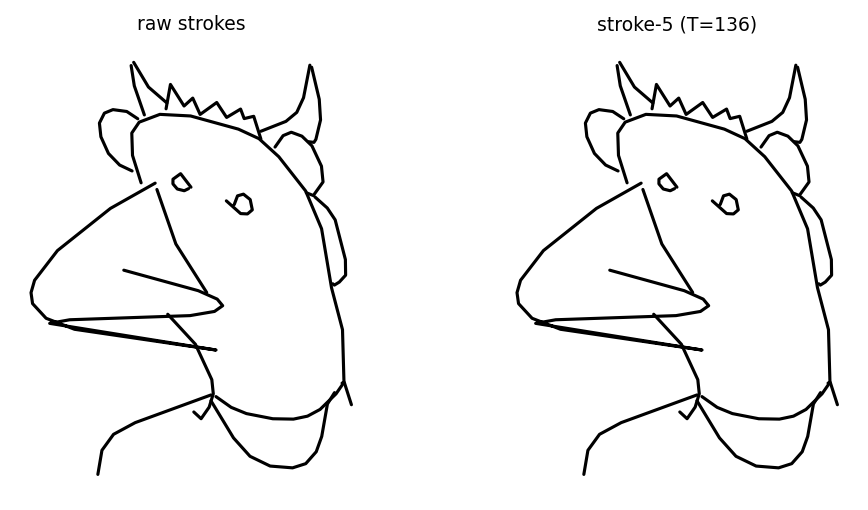

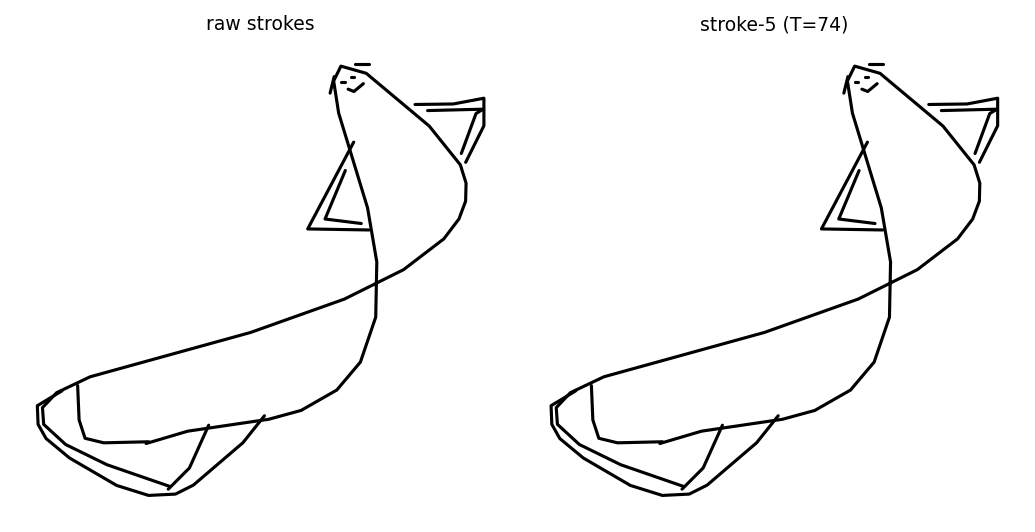

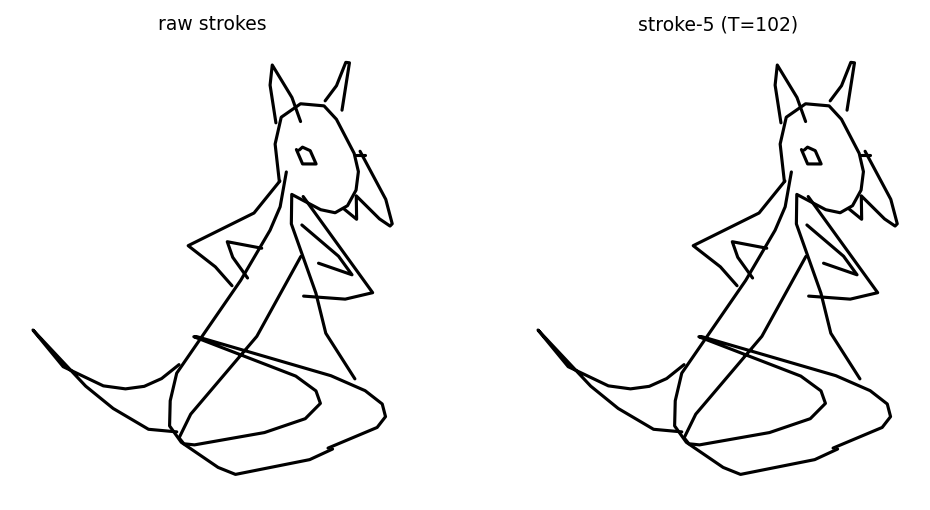

--- val ---


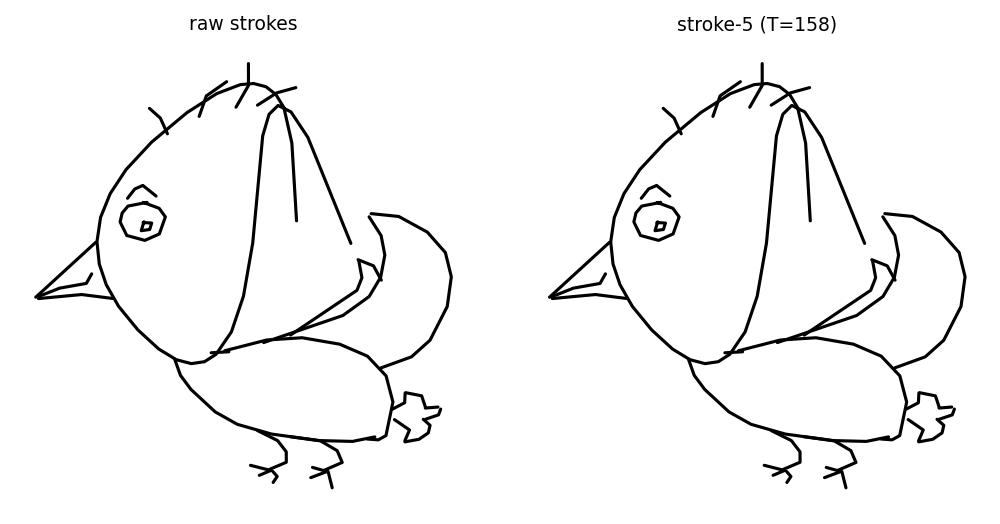

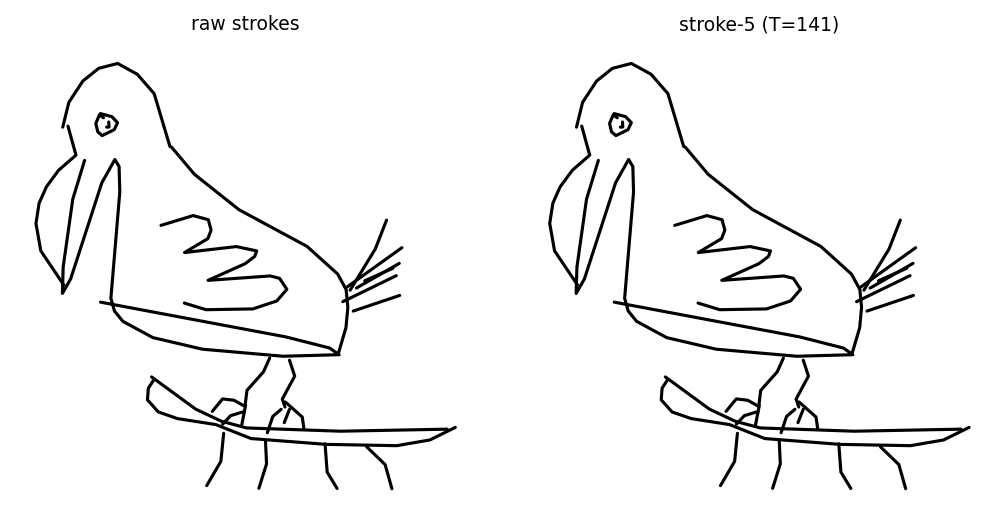

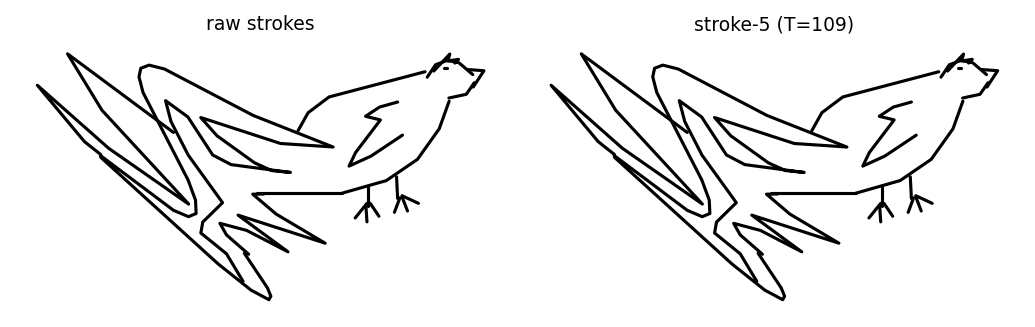

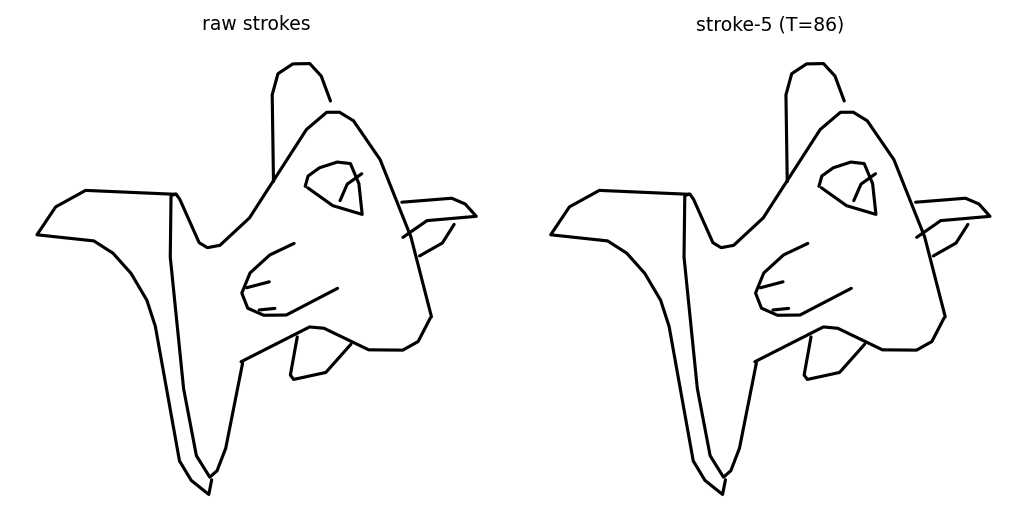

In [4]:
for split in ("train", "val"):
    print(f"--- {split} ---")
    for i in range(4):
        path = OUT / "inspect" / f"{split}_raw_vs_s5_{i}.png"
        if path.exists():
            display(Image(filename=str(path)))

## 4. Histogramas de longitud

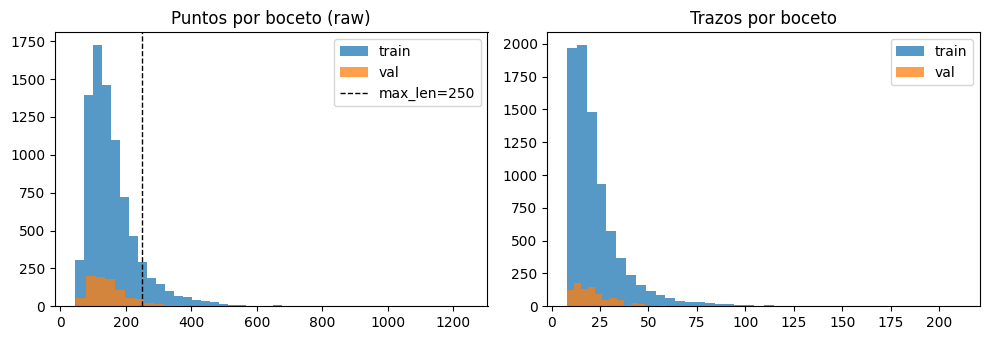

In [5]:
train = load_raw_split("train", ROOT)
val = load_raw_split("val", ROOT)

def point_counts(samples):
    return np.array([sum(len(st) for st in s["strokes"]) for s in samples])

def stroke_counts(samples):
    return np.array([len(s["strokes"]) for s in samples])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(point_counts(train), bins=40, alpha=0.75, label="train")
axes[0].hist(point_counts(val), bins=40, alpha=0.75, label="val")
axes[0].axvline(250, color="k", ls="--", lw=1, label="max_len=250")
axes[0].set_title("Puntos por boceto (raw)")
axes[0].legend()

axes[1].hist(stroke_counts(train), bins=40, alpha=0.75, label="train")
axes[1].hist(stroke_counts(val), bins=40, alpha=0.75, label="val")
axes[1].set_title("Trazos por boceto")
axes[1].legend()
fig.tight_layout()
plt.show()

## 5. Cache preprocesado (`stroke5.npz`)

In [6]:
cache = np.load(OUT / "preprocessed" / "stroke5.npz", allow_pickle=True)
train_s5 = cache["train"]
val_s5 = cache["val"]
scale = float(cache["scale"])
print(f"train sequences: {len(train_s5)}  val: {len(val_s5)}  scale={scale:.4f}")
print(f"ejemplo train[0] shape={train_s5[0].shape}  (T, 5) = (dx, dy, p1, p2, p3)")
print(train_s5[0][:3])

train sequences: 7330  val: 825  scale=50.8887
ejemplo train[0] shape=(143, 5)  (T, 5) = (dx, dy, p1, p2, p3)
[[ 3.9712133   6.343839    1.          0.          0.        ]
 [ 2.811141   -1.1217669   1.          0.          0.        ]
 [ 0.252825   -0.17676958  1.          0.          0.        ]]


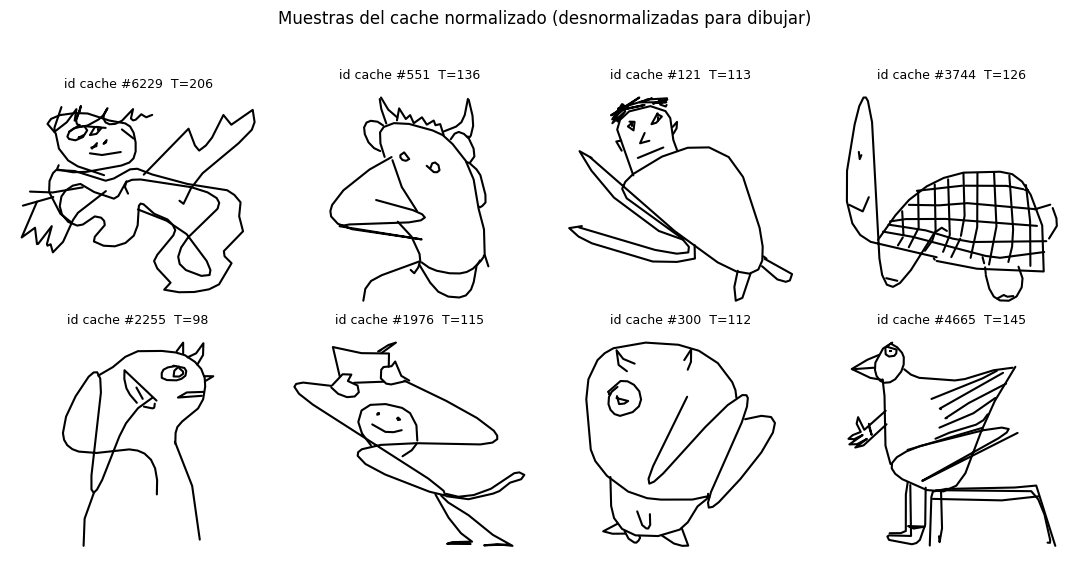

In [7]:
rng = np.random.default_rng(0)
idx = rng.choice(len(train_s5), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for ax, i in zip(axes.ravel(), idx):
    seq = denormalize_stroke5(train_s5[i], scale)
    draw_stroke5(seq, ax=ax, title=f"id cache #{i}  T={len(seq)}")
fig.suptitle("Muestras del cache normalizado (desnormalizadas para dibujar)", y=1.02)
fig.tight_layout()
plt.show()

## 6. Prefijos para sketch completion

Simulación de lo que pedirá el lab: mismos trazos iniciales, el resto oculto.

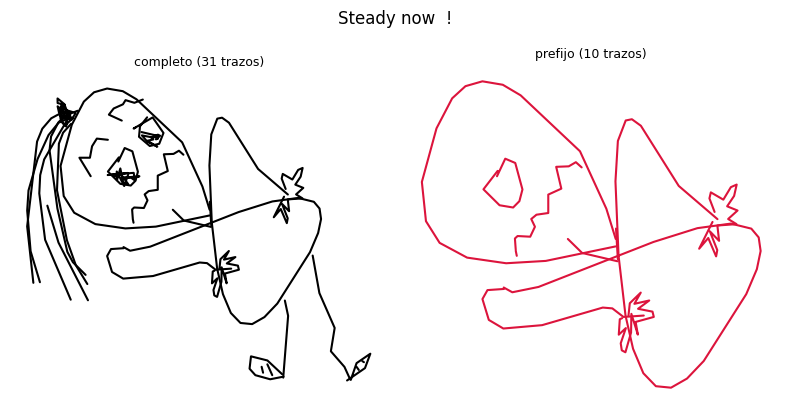

In [8]:
def prefix_strokes(strokes, n_keep: int):
    n_keep = max(1, min(n_keep, len(strokes)))
    return strokes[:n_keep]

sample = train[int(rng.integers(0, len(train)))]
n_prefix = max(3, len(sample["strokes"]) // 3)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_sketch(sample["strokes"], ax=axes[0], title=f"completo ({len(sample['strokes'])} trazos)")
draw_sketch(
    prefix_strokes(sample["strokes"], n_prefix),
    ax=axes[1],
    title=f"prefijo ({n_prefix} trazos)",
    color="crimson",
)
fig.suptitle(sample.get("description", sample["id"]), y=1.02)
fig.tight_layout()
plt.show()

## Siguiente

Con `outputs/preprocessed/stroke5.npz` listo, el siguiente paso es entrenar el **Sketch-RNN VAE** (generación + completion).